#### Exercise 2
Ahmet Meriç Kızıltaş

In [1]:
!pip install umap-learn
!pip install scikit-learn

**a)** *On Sheet 3, we investigated the effect of data standardization on PCA. Will standardizing the
input of t-SNE and UMAP also affect the resulting embeddings? Justify your answer. (2P)*


Yes, it will have an effect, because both t-SNE and UMAP use similarity scores based on the euclidean distance between data points, which is "warped" when standardizing the input.

**b)** *Experimentally confirm your answer by plotting the iris dataset with t-SNE and UMAP with
default settings, respectively, both without and with standardization. Use different colors for each
species and an equal aspect ratio to avoid distorting the plots. (2P)*


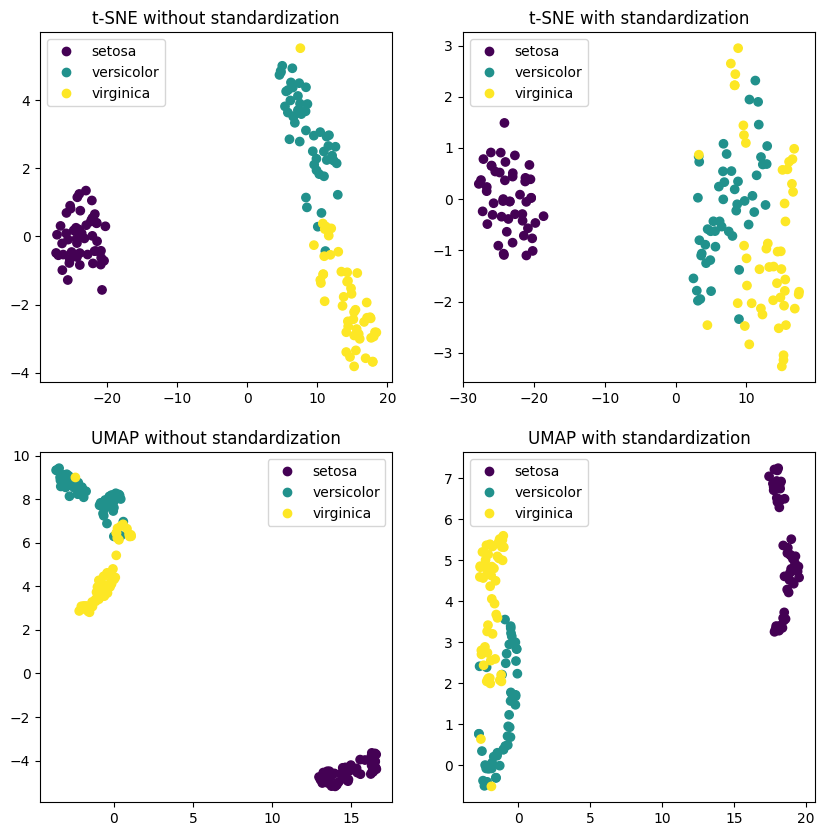

In [2]:
import sklearn as ski
import umap
import matplotlib.pyplot as plt
data = ski.datasets.load_iris()
data_standard = ski.preprocessing.StandardScaler().fit(data.data).transform(data.data)
classes = data.target
data_tsne = ski.manifold.TSNE().fit_transform(data.data)
data_tsne_standard = ski.manifold.TSNE().fit_transform(data_standard)
data_umap = umap.UMAP().fit_transform(data.data)
data_umap_standard = umap.UMAP().fit_transform(data_standard)

fig, ((ax1, ax2) ,(ax3, ax4)) = plt.subplots(2,2, figsize=(10,10))
sct1 = ax1.scatter(data_tsne[:,0], data_tsne[:,1], c=classes)
sct2 = ax2.scatter(data_tsne_standard[:,0], data_tsne_standard[:,1], c=classes)
sct3 = ax3.scatter(data_umap[:,0], data_umap[:,1], c=classes)
sct4 = ax4.scatter(data_umap_standard[:,0], data_umap_standard[:,1], c=classes)
ax1.set_title("t-SNE without standardization")
ax2.set_title("t-SNE with standardization")
ax3.set_title("UMAP without standardization")
ax4.set_title("UMAP with standardization")
fig = ax1.legend(sct1.legend_elements()[0], data.target_names)
fig = ax2.legend(sct2.legend_elements()[0], data.target_names)
fig = ax3.legend(sct3.legend_elements()[0], data.target_names)
fig = ax4.legend(sct4.legend_elements()[0], data.target_names)
plt.show()

As we suspected, there is a distortion when the data is standardized with both methods. In particular, we see that the standardized t-SNE does a far worse job separating *versicolor* and *virginica*.

**c)** *In the lecture, we discussed the relevance of initialization in t-SNE and UMAP. Run both methods
on the standardized data with multiple random initializations, keeping track of the seed to keep
your results reproducible. Comment on the resulting variability. Could it affect the interpretation
of the plots? (3P)*

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


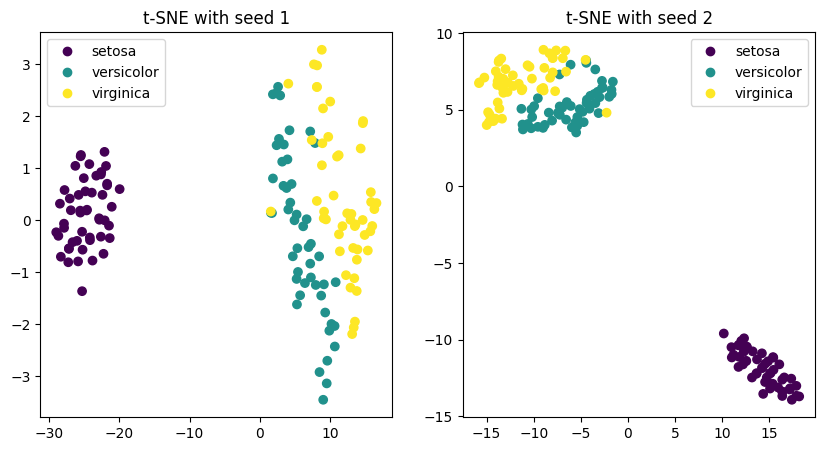

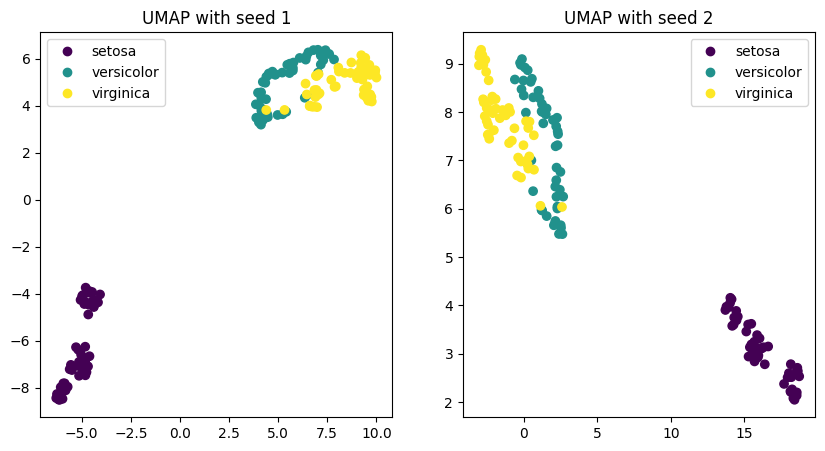

In [3]:
seed1 = 1
seed2 = 2

data_tsne_1 = ski.manifold.TSNE(init = "random", random_state = seed1).fit_transform(data_standard)
data_tsne_2 = ski.manifold.TSNE(init = "random", random_state = seed2).fit_transform(data_standard)
data_umap_1 = umap.UMAP(init = "random", random_state = seed1).fit_transform(data_standard)
data_umap_2 = umap.UMAP(init = "random", random_state = seed2).fit_transform(data_standard)

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,5))
sct1 = ax1.scatter(data_tsne_1[:,0], data_tsne_1[:,1], c=classes)
sct2 = ax2.scatter(data_tsne_2[:,0], data_tsne_2[:,1], c=classes)
ax1.set_title("t-SNE with seed 1")
ax2.set_title("t-SNE with seed 2")
fig = ax1.legend(sct1.legend_elements()[0], data.target_names)
fig = ax2.legend(sct2.legend_elements()[0], data.target_names)
plt.show()
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,5))
sct1 = ax1.scatter(data_umap_1[:,0], data_umap_1[:,1], c=classes)
sct2 = ax2.scatter(data_umap_2[:,0], data_umap_2[:,1], c=classes)
ax1.set_title("UMAP with seed 1")
ax2.set_title("UMAP with seed 2")
fig = ax1.legend(sct1.legend_elements()[0], data.target_names)
fig = ax2.legend(sct2.legend_elements()[0], data.target_names)
plt.show()

We observe that plots with different seeds have noticeably different appearance. They show the clusters in different regions of the plot, and the relative sizes of the clusters is also variable. This could compromise the legibility of the plot. However, the cluster configuration is the same on all plots: wee see that the varieties *versicolor* and *virginica* are really close to each other, while variety *setosa* forms an observably different cluster.

**d)** *Perplexity is a key parameter in t-SNE. Try different values, e.g., {2, 8, 30, 100}, and comment on
your observations. (3P)*

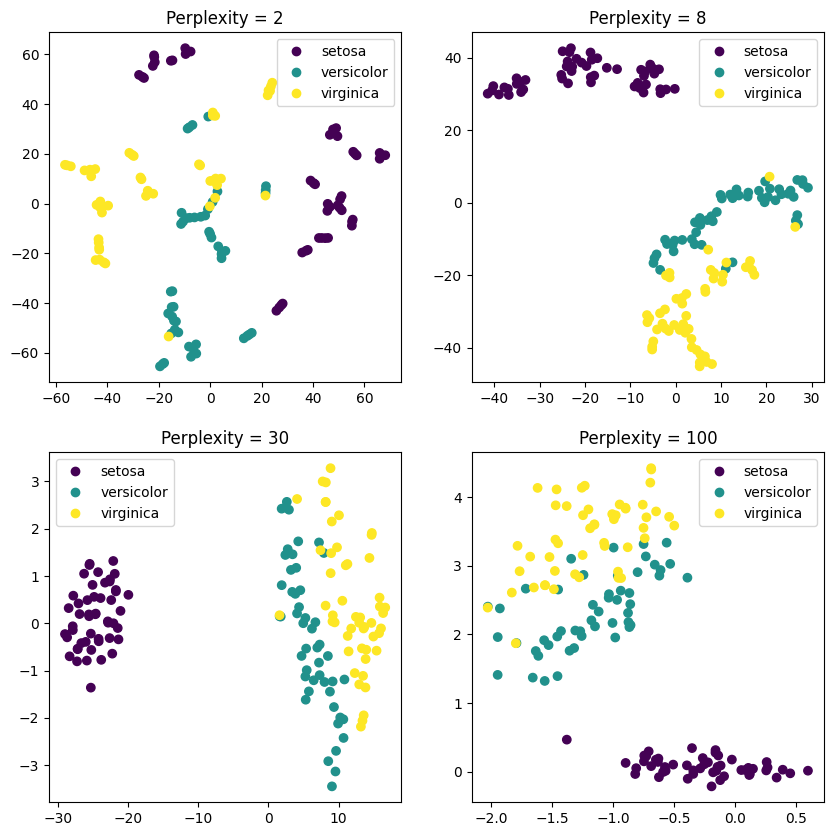

In [4]:
data_tsne_1 = ski.manifold.TSNE(init = "random", random_state = seed1, perplexity = 2).fit_transform(data_standard)
data_tsne_2 = ski.manifold.TSNE(init = "random", random_state = seed1, perplexity = 8).fit_transform(data_standard)
data_tsne_3 = ski.manifold.TSNE(init = "random", random_state = seed1, perplexity = 30).fit_transform(data_standard)
data_tsne_4 = ski.manifold.TSNE(init = "random", random_state = seed1, perplexity = 100).fit_transform(data_standard)

fig, ((ax1, ax2) ,(ax3, ax4)) = plt.subplots(2,2, figsize=(10,10))
sct1 = ax1.scatter(data_tsne_1[:,0], data_tsne_1[:,1], c=classes)
sct2 = ax2.scatter(data_tsne_2[:,0], data_tsne_2[:,1], c=classes)
sct3 = ax3.scatter(data_tsne_3[:,0], data_tsne_3[:,1], c=classes)
sct4 = ax4.scatter(data_tsne_4[:,0], data_tsne_4[:,1], c=classes)
ax1.set_title("Perplexity = 2")
ax2.set_title("Perplexity = 8")
ax3.set_title("Perplexity = 30")
ax4.set_title("Perplexity = 100")
fig = ax1.legend(sct1.legend_elements()[0], data.target_names)
fig = ax2.legend(sct2.legend_elements()[0], data.target_names)
fig = ax3.legend(sct3.legend_elements()[0], data.target_names)
fig = ax4.legend(sct4.legend_elements()[0], data.target_names)
plt.show()

We can see that different values of perplexity cause different cluster structures: with low perplexity values(2) we observe no clusters, as the preservation of local distances cause points of all varieties to scatter around the plot. With higher values(8, 30, 100), we can appreciate scatters that separate the different varieties. It seems that as perplexity grows, the method does worse in separating the varieties *versicolor* and *virginica*, as the global distance between their clusters is relatively low, meanwhile the shape and relative distance between the plots should be more accurate with the highest values(100).

**e)** *The number of neighbors to preserve is a key parameter in UMAP. Try the same values as previously for perplexity. Comment on similarities and differences compared to t-SNE. (2P)*


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


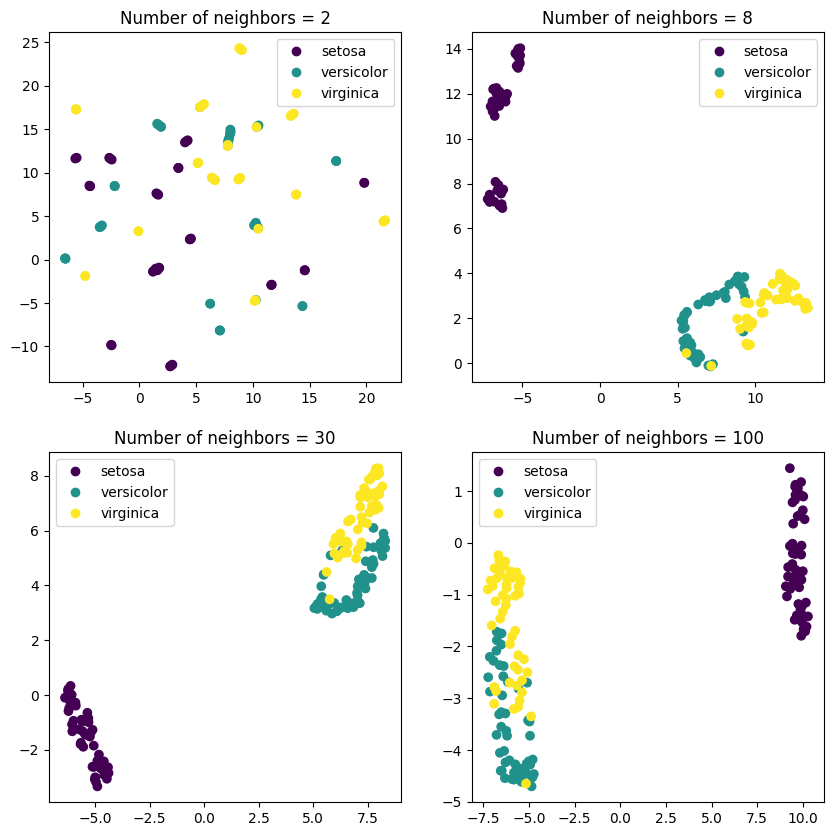

In [5]:
data_umap_1 = umap.UMAP(init = "random", random_state = seed1, n_neighbors = 2).fit_transform(data_standard)
data_umap_2 = umap.UMAP(init = "random", random_state = seed1, n_neighbors = 8).fit_transform(data_standard)
data_umap_3 = umap.UMAP(init = "random", random_state = seed1, n_neighbors = 30).fit_transform(data_standard)
data_umap_4 = umap.UMAP(init = "random", random_state = seed1, n_neighbors = 100).fit_transform(data_standard)

fig, ((ax1, ax2) ,(ax3, ax4)) = plt.subplots(2,2, figsize=(10,10))
sct1 = ax1.scatter(data_umap_1[:,0], data_umap_1[:,1], c=classes)
sct2 = ax2.scatter(data_umap_2[:,0], data_umap_2[:,1], c=classes)
sct3 = ax3.scatter(data_umap_3[:,0], data_umap_3[:,1], c=classes)
sct4 = ax4.scatter(data_umap_4[:,0], data_umap_4[:,1], c=classes)
ax1.set_title("Number of neighbors = 2")
ax2.set_title("Number of neighbors = 8")
ax3.set_title("Number of neighbors = 30")
ax4.set_title("Number of neighbors = 100")
fig = ax1.legend(sct1.legend_elements()[0], data.target_names)
fig = ax2.legend(sct2.legend_elements()[0], data.target_names)
fig = ax3.legend(sct3.legend_elements()[0], data.target_names)
fig = ax4.legend(sct4.legend_elements()[0], data.target_names)
plt.show()

Similarly to the previous section, the parameter *n_neighbors* balances the weight of local vs global structures in the plot. With the lowest value(2), we see no observable clusters forming, while the rest of the plots have relatively similar readings, with two observable clusters at far away positions, while still a small gap between *virginica* and *versicolor*.

**f)** *UMAP has min_dist as an additional parameter. Illustrate its effect by trying out different
settings and comment on its effect. (2P)*


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


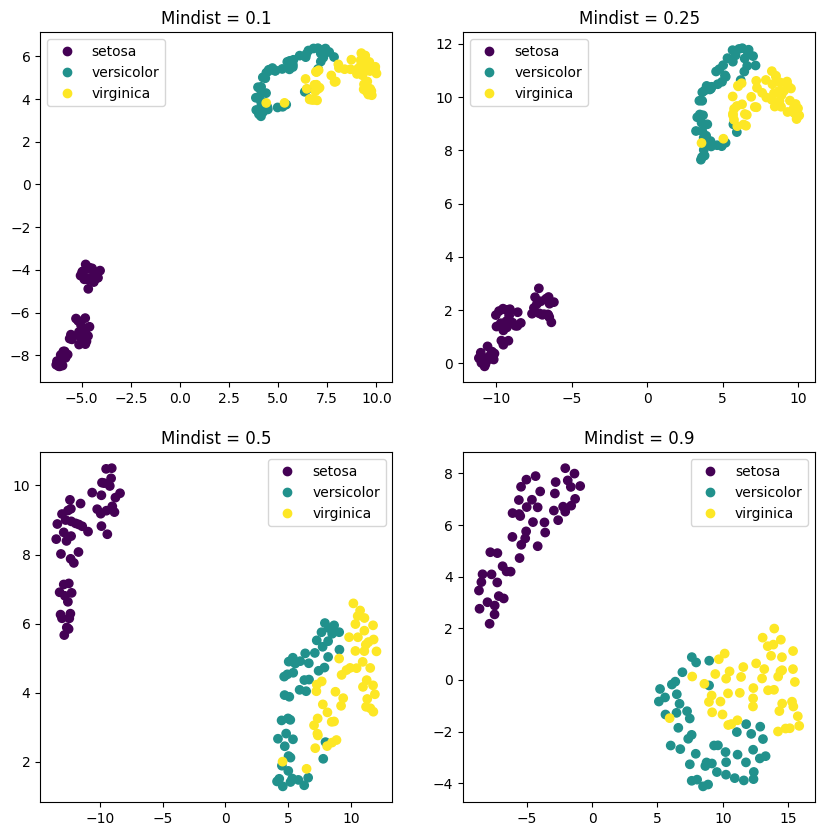

In [6]:
data_umap_1 = umap.UMAP(init = "random", random_state = seed1, min_dist = 0.1).fit_transform(data_standard)
data_umap_2 = umap.UMAP(init = "random", random_state = seed1, min_dist = 0.25).fit_transform(data_standard)
data_umap_3 = umap.UMAP(init = "random", random_state = seed1, min_dist = 0.5).fit_transform(data_standard)
data_umap_4 = umap.UMAP(init = "random", random_state = seed1, min_dist = 0.9).fit_transform(data_standard)

fig, ((ax1, ax2) ,(ax3, ax4)) = plt.subplots(2,2, figsize=(10,10))
sct1 = ax1.scatter(data_umap_1[:,0], data_umap_1[:,1], c=classes)
sct2 = ax2.scatter(data_umap_2[:,0], data_umap_2[:,1], c=classes)
sct3 = ax3.scatter(data_umap_3[:,0], data_umap_3[:,1], c=classes)
sct4 = ax4.scatter(data_umap_4[:,0], data_umap_4[:,1], c=classes)
ax1.set_title("Mindist = 0.1")
ax2.set_title("Mindist = 0.25")
ax3.set_title("Mindist = 0.5")
ax4.set_title("Mindist = 0.9")
fig = ax1.legend(sct1.legend_elements()[0], data.target_names)
fig = ax2.legend(sct2.legend_elements()[0], data.target_names)
fig = ax3.legend(sct3.legend_elements()[0], data.target_names)
fig = ax4.legend(sct4.legend_elements()[0], data.target_names)
plt.show()

As we expected, the main effect of changing the value of the parameter *min_dist* is changing the relative sparseness of the clusters, with higher values of *min_dist* resulting in more spread-out clusters in the plot. Otherwise, the relative size and position of the clusters is generally the same regardless of the value of the parameter.